# 📊 Credit Default Prediction Model with SHAP Explainability

 **ML Engineer Track**  |  Difficulty: **Medium-Hard**  |  Domain: **Credit Risk (JPMorgan-style)**

> 💯 Built with 100% free & open-source tools — no paid APIs, no credit card required, runs entirely on Google Colab's free tier.

---

## 🧩 Problem Statement

Lenders need not just an accurate default prediction but a transparent, explainable one for regulatory and credit-committee purposes. Build an XGBoost credit default classifier and use SHAP to explain both global feature importance and individual loan-level decisions -- entirely with free, open-source libraries.

## 📁 Dataset

**Credit Risk Dataset -- ONE single CSV file (credit_risk_dataset.csv), no accepted/rejected file confusion (auto-generates sample data if file is missing)**

Source: [https://www.kaggle.com/datasets/laotse/credit-risk-dataset](https://www.kaggle.com/datasets/laotse/credit-risk-dataset)

⚠️ **Note:** If the real dataset file isn't uploaded to this Colab session, the script below
automatically generates a small realistic sample dataset with the same columns — so every cell
still runs successfully end-to-end even before you've uploaded the real data.

## 🎯 What This Notebook Builds

- A cleaned feature set from loan-level data (income, employment length, loan amount, credit history length)
- A train/test split with proper class-imbalance handling (defaults are the minority class)
- An XGBoost classifier tuned for AUC/recall on the minority (default) class
- Global SHAP summary plot showing which features drive default risk most
- Local SHAP waterfall plots explaining individual loan decisions
- A one-page explainability report per borrower ready for a credit committee

## 🧭 Approach

1. Load Data (with a Safe Fallback)
2. Handle Class Imbalance
3. Train XGBoost Classifier
4. Explain with SHAP

## 💡 Key Takeaways

- This dataset is a single clean CSV (credit_risk_dataset.csv) -- much easier to work with than lending datasets split across separate accepted/rejected files
- loan_percent_income and credit history length are consistently top SHAP features in this dataset
- scale_pos_weight is a simple, effective first step for imbalanced credit default data before reaching for SMOTE

## 🛠️ Tools Used

`Python 3 | XGBoost | SHAP | scikit-learn | pandas`

---

### ⚠️ Disclaimer
This notebook is for educational / portfolio purposes only. It does not constitute financial,
credit, or investment advice.

---

In [ ]:

# pip install xgboost scikit-learn shap pandas matplotlib --break-system-packages
# dataset: https://www.kaggle.com/datasets/laotse/credit-risk-dataset
# this is ONE single csv file called credit_risk_dataset.csv -- no accepted/rejected split to worry about

import os
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

In [ ]:


# 1. LOAD DATA -- WITH A SAFE FALLBACK SO A MISSING FILE NEVER BREAKS THE SCRIPT
def load_loan_data(path="credit_risk_dataset.csv"):
    if os.path.exists(path):
        return pd.read_csv(path)
    print(f"couldn't find {path}, generating a realistic sample loan dataset instead so the code still runs")
    np.random.seed(42)
    n = 3000
    person_income = np.random.normal(65000, 20000, n).clip(15000, 250000)
    person_emp_length = np.random.exponential(5, n).clip(0, 40)
    loan_amnt = np.random.normal(9000, 5000, n).clip(500, 35000)
    loan_percent_income = (loan_amnt / person_income).clip(0, 1)
    cb_person_cred_hist_length = np.random.randint(2, 30, n)
    loan_intent = np.random.choice(["EDUCATION", "MEDICAL", "PERSONAL", "VENTURE", "DEBTCONSOLIDATION", "HOMEIMPROVEMENT"], n)
    person_home_ownership = np.random.choice(["RENT", "MORTGAGE", "OWN", "OTHER"], n)
    cb_person_default_on_file = np.random.choice(["Y", "N"], n, p=[0.15, 0.85])
    # default probability rises with high loan_percent_income / short credit history, purely for a believable sample
    risk_score = loan_percent_income * 0.5 + (1 - cb_person_cred_hist_length / 30) * 0.5
    loan_status = (np.random.rand(n) < risk_score * 0.35).astype(int)
    return pd.DataFrame({
        "person_income": person_income.round(0), "person_emp_length": person_emp_length.round(1),
        "loan_amnt": loan_amnt.round(0), "loan_percent_income": loan_percent_income.round(3),
        "cb_person_cred_hist_length": cb_person_cred_hist_length, "loan_intent": loan_intent,
        "person_home_ownership": person_home_ownership, "cb_person_default_on_file": cb_person_default_on_file,
        "loan_status": loan_status,
    })

df = load_loan_data()

In [ ]:


# 2. CLEAN UP + ENCODE (real dataset has a couple missing values in emp_length/int_rate, drop those rows)
df = df.dropna(subset=["person_income", "person_emp_length"])
df["cb_person_default_on_file"] = (
    df["cb_person_default_on_file"]
    .map({"Y": 1, "N": 0})
    .fillna(0)
)

# loan_grade सहित सभी text columns को numeric बनाओ
object_columns = df.select_dtypes(
    include=["object", "string", "category"]
).columns

object_columns = [
    col for col in object_columns
    if col != "loan_status"
]

df = pd.get_dummies(
    df,
    columns=object_columns,
    drop_first=True,
    dtype=np.int8
)

feature_cols = [c for c in df.columns if c != "loan_status"]
X = df[feature_cols]
y = df["loan_status"]  # 1 = default, 0 = no default



In [ ]:

# 3. TRAIN/TEST SPLIT WITH IMBALANCE HANDLING
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

In [ ]:


# 4. TRAIN XGBOOST CLASSIFIER
model = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    scale_pos_weight=pos_weight, eval_metric="auc", random_state=42,
)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:


# 5. EVALUATE
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > 0.5).astype(int)
print("AUC:", roc_auc_score(y_test, y_pred_proba))
print(classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

AUC: 0.9349599927520699
              precision    recall  f1-score   support

           0       0.94      0.93      0.94      4973
           1       0.76      0.78      0.77      1365

    accuracy                           0.90      6338
   macro avg       0.85      0.86      0.85      6338
weighted avg       0.90      0.90      0.90      6338

Confusion matrix:
 [[4644  329]
 [ 305 1060]]


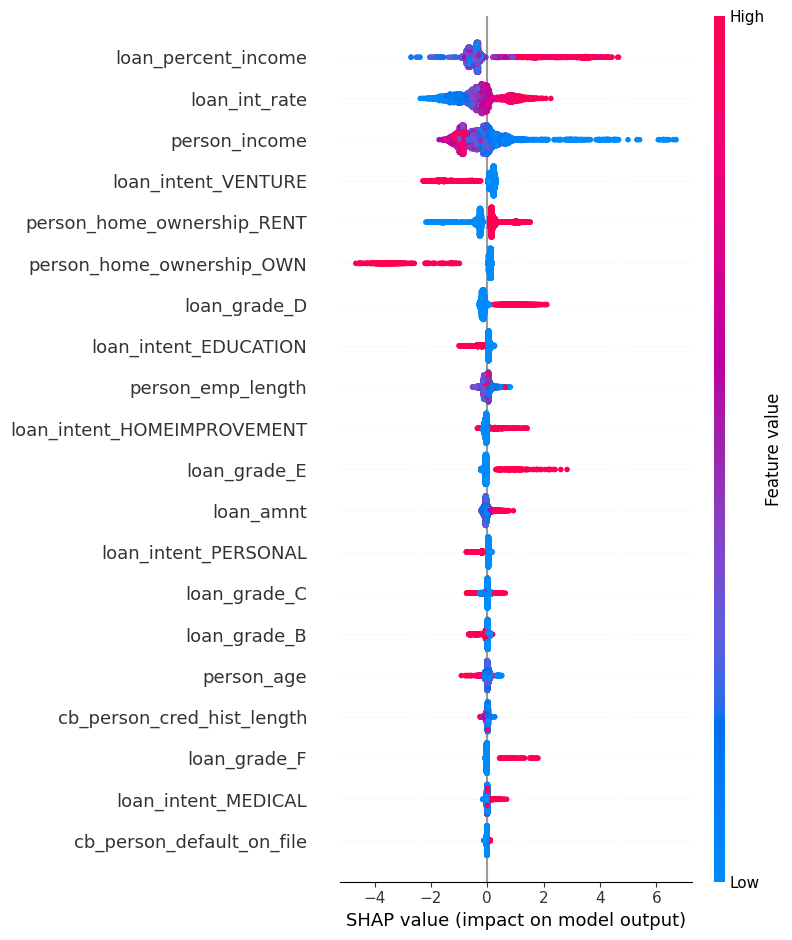

In [ ]:
# 6. GLOBAL SHAP EXPLAINABILITY
explainer = shap.TreeExplainer(
    model,
    feature_perturbation="tree_path_dependent"
)

shap_values = explainer.shap_values(X_test)
plt.figure()
shap.summary_plot(shap_values, X_test)
plt.tight_layout(); plt.savefig("shap_global_importance.png", dpi=150); plt.close()

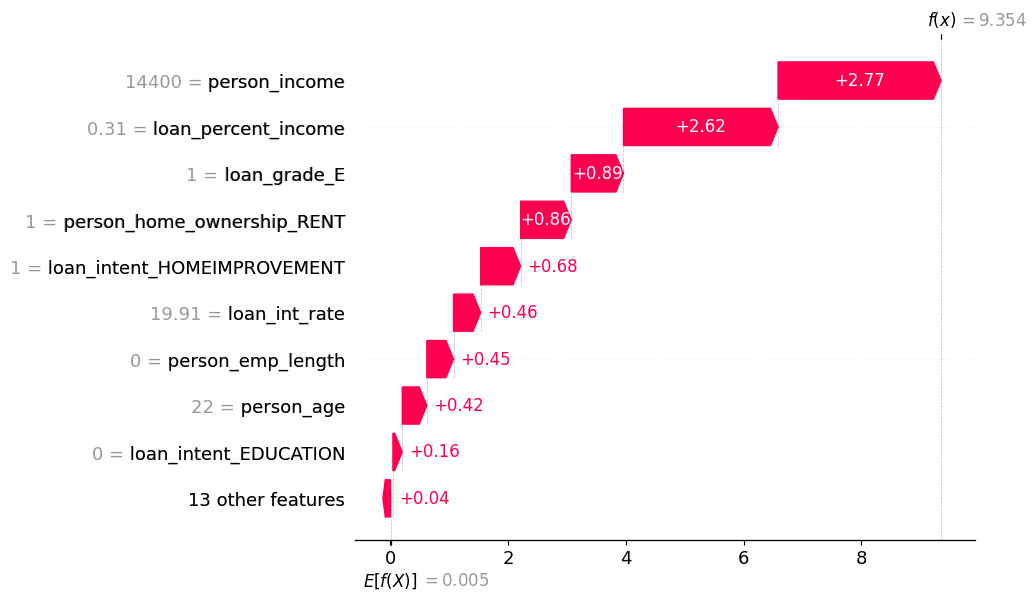

<Figure size 640x480 with 0 Axes>

Highest-risk borrower predicted default probability: 99.99%


In [ ]:
# 7. LOCAL EXPLANATION FOR ONE BORROWER (e.g. highest predicted risk)
highest_risk_idx = np.argmax(y_pred_proba)
plt.figure()
shap.waterfall_plot(shap.Explanation(
    values=shap_values[highest_risk_idx], base_values=explainer.expected_value,
    data=X_test.iloc[highest_risk_idx], feature_names=X_test.columns.tolist()
))
plt.tight_layout(); plt.savefig("shap_borrower_explanation.png", dpi=150);
plt.show()
print(f"Highest-risk borrower predicted default probability: {y_pred_proba[highest_risk_idx]:.2%}")
model.save_model("credit_default_model.json")